### **Zomato Data Analysis Project**

1) What type of restaurant do the majority of customers order from?

2) How many votes has each type of restaurant received from customers?

3) What are the ratings that the majority of restaurants have received?

4) Zomato has observed that most couples order most of their food online. What is their average spending on each order?

5) Which mode (online or offline) has received the maximum rating?
6) Which type of restaurant received more offline orders, so that Zomato can place 

# **Step 1 - Importing Libraries**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Step 2 - Creating Data Frame**

In [26]:
dataframe=pd.read_csv('Zomato data .csv')

In [28]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [30]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


# Convert datatype of column - rate

In [39]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0]
    return float(value)
dataframe['rate']=dataframe['rate'].apply(handleRate)
print(dataframe.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [41]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


**Q1 : What type of restaurant do the majority of customers order from?**

In [44]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0.5, 0, 'type of restaurant')

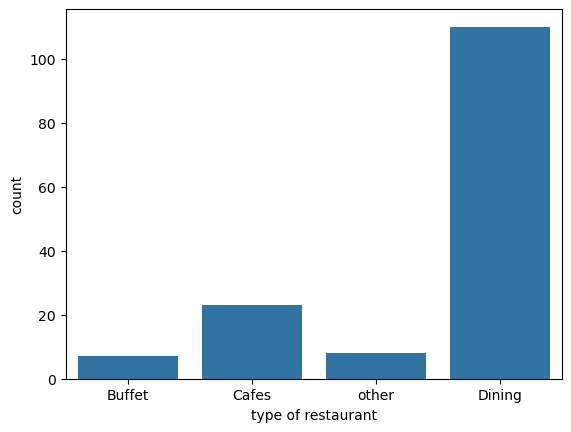

In [46]:
sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel("type of restaurant")

### **conclusion of Q1 - majority of the restaurants falls in dining category**

---

### **Q2 : How many votes has each type of restaurant received from customers?**

Text(0, 0.5, 'votes')

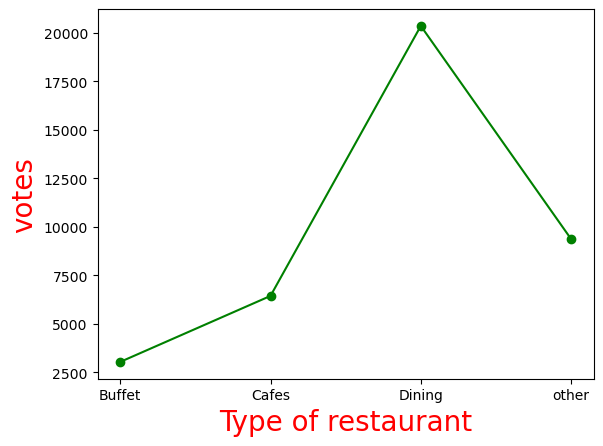

In [67]:
grouped_data=dataframe.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({'votes':grouped_data})
plt.plot(result,c='green',marker='o')
plt.xlabel("Type of restaurant",c="red",size=20)
plt.ylabel("votes",c="red",size=20)


### **conclusion of Q2 - dining restaurants has received maximum votes**

-----

### **Q3 : What are the ratings that the majority of restaurants have received?**

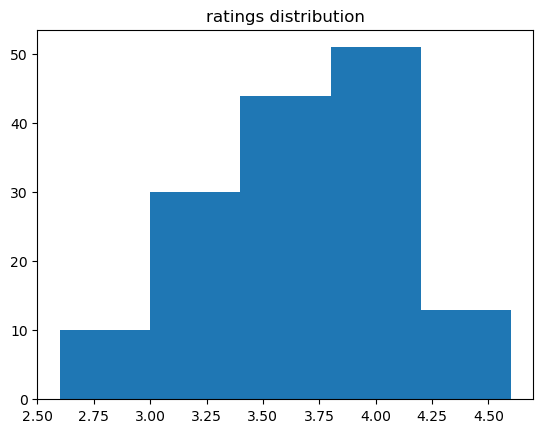

In [77]:
plt.hist(dataframe['rate'],bins=5)
plt.title("ratings distribution")
plt.show()

### **Conclusion of Q3 : The majority restaurants received ratings from 3.5 to 4**

------

### **Q4 : Zomato has observed that most couples order most of their food online. What is their average spending on each order?**

### **Average order spending by couples**

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

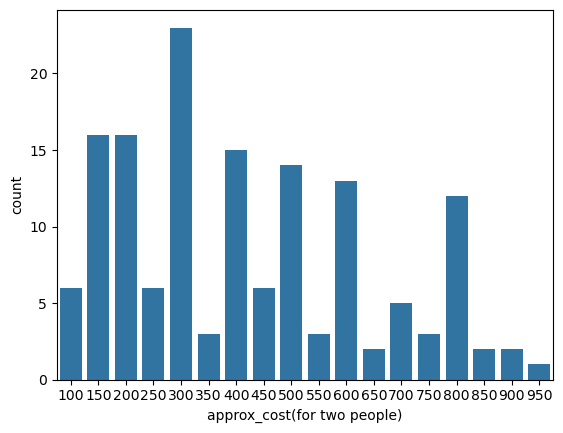

In [85]:
couple_data=dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)

### **Conclusion of Q4 : the majority of couples prefer restaurants with an approximate cost of 300 rupees**

----

### **Q5 : Which mode (online or offline) has received the maximum rating?**

<Axes: xlabel='online_order', ylabel='rate'>

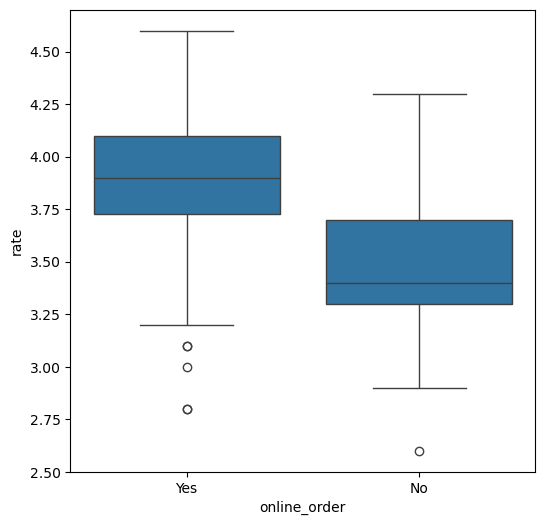

In [90]:
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order',y='rate',data=dataframe)
            

### **Conclusion of Q5 : offline order received lower rating in comparision to online order**

------

### **Q6 : Which type of restaurant received more offline orders, so that Zomato can place**

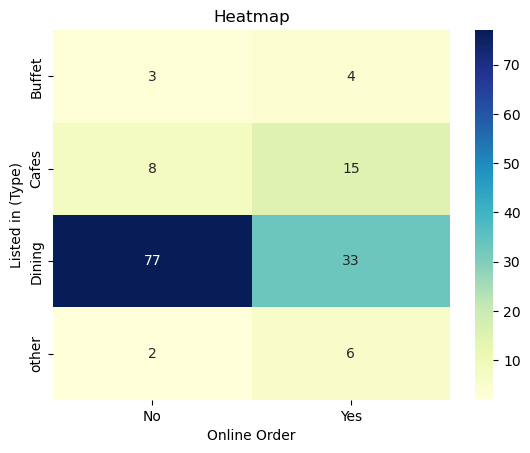

In [95]:
pivot_table=dataframe.pivot_table(index='listed_in(type)',columns='online_order',aggfunc='size',fill_value=0)
sns.heatmap(pivot_table,annot=True,cmap="YlGnBu",fmt='d')
plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed in (Type)")
plt.show()

### **conclusion of Q6 : Dining restaurants primarily accept offline orders where as cafes primarily receive online orders. This suggests that clients prefers orders in person at restaurants , but prefer online orders at cafes**